In [2]:
import importlib
import pandas as pd
from IPython.display import display
import framework
importlib.reload(framework)
from framework import WheatFramework, generate_group_folds,save_model, save_results, run_fold_with_trainer


CHANGE ACCORDING TO YOUR PATHS !!

In [3]:

# Update paths if different on your machine
excel_path = r".\labeling.xlsx"
data_path = r".\data"


Searching for images in: c:\Users\PC\Desktop\AI_TARBIL\code\data
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_01-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-01
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_02-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-02
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_03-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-03
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_05-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-05
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_06-10_12-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-06
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_07-09_53-K1-1X.jpeg (matched date in filename)

,path,label
0,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
1,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
2,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
3,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
4,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
5,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
6,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
7,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0


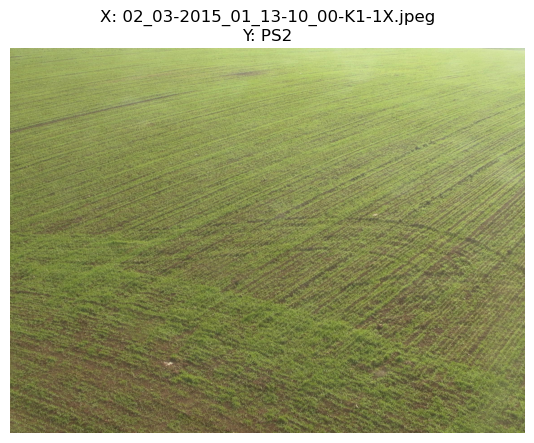

In [4]:

wf = WheatFramework(excel_path=excel_path, root_dir=data_path)

try:
    meta_df = wf.get_dataframe()
except Exception as e:
    print("Error loading data:", e)
    meta_df = pd.DataFrame()

if not meta_df.empty:
    X, y, folds = wf.get_splits(meta_df, n_splits=5)
    print(f"Total matched images: {len(X)}")

    # Print label mapping (encoded -> string label)
    classes = list(wf.le.classes_)
    mapping = {i: cls for i, cls in enumerate(classes)}
    print("\nLabel mapping (encoded -> label):")
    for k, v in mapping.items():
        print(k, ":", v)

    print("\nSample matched paths and labels:")
    display(meta_df[['path', 'label']].head(8))

    # Visual verification: display one random sample image and its label
    wf.get_sample(X, y)
else:
    print("No images matched. Review previous prints above for column mapping and search path.")


In [5]:
# Count images by group and stage
import pandas as pd

if 'meta_df' not in globals() or meta_df.empty:
    print("No `meta_df` available. Run the loader cell first (the one that creates `meta_df`).")
else:
    ct = pd.crosstab(meta_df['group_id'], meta_df['label'])
    ct['total'] = ct.sum(axis=1)
    ct = ct.sort_values('total', ascending=False)

    print('\nImages per group × stage (top 20 groups):')
    display(ct.head(20))

    print('\nStage totals:')
    stage_totals = ct.drop(columns=['total']).sum(axis=0).to_frame(name='count')
    display(stage_totals)



Images per group × stage (top 20 groups):


label,PS0,PS1,PS2,PS3,PS4,PS5,PS6,PS7,total
group_id,,,,,,,,,
7,92,12,15,6,14,21,12,28,200
6,22,20,34,28,47,4,18,16,189
10,31,24,18,28,35,13,25,14,188
1,20,19,37,15,47,12,8,23,181
9,101,17,15,5,15,8,20,0,181
2,12,37,21,24,22,9,19,30,174
3,19,22,26,40,26,14,11,16,174
4,7,37,5,18,36,15,13,31,162
8,45,14,17,4,39,21,3,17,160



Stage totals:


,count
label,
PS0,360
PS1,220
PS2,208
PS3,189
PS4,306
PS5,123
PS6,143
PS7,193


In [6]:
missing_data_per_station, missing_dates_for_stations = wf.get_stagewise_missing_data()



Stage: PS0

Stage: PS1

Stage: PS2

Stage: PS3


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in


Stage: PS4

Stage: PS5

Stage: PS6

Stage: PS7


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in

In [7]:

print("\nMissing data per station:")
##make a table with station, stage, and only missing count
print("Station\t", end="")
for i in range(1,9):
    print(f"\tPS{i}", end="")
print()
for station, stages in missing_data_per_station.items():
    print(f"{station}", end="")
    for stage, info in stages.items():
        print(f"\t{info['missing_count']}", end="")
    print()


Missing data per station:
Station		PS1	PS2	PS3	PS4	PS5	PS6	PS7	PS8
02.02_2014	2	1	0	0	9	4	3	12
02.03_2013	2	14	3	11	14	0	2	1
02.03_2014	1	0	3	14	4	6	2	6
02.04_2013	14	7	13	1	9	0	0	-1
02.05_2013	29	0	7	5	20	2	8	17
02.06_2016	3	14	2	1	0	10	2	-1
06.01_2013	21	13	0	0	15	2	0	-1
06.02_2013	10	2	8	14	5	0	15	3
06.02_2016	62	4	6	4	17	2	13	15
11.03_2016	18	4	2	0	4	8	0	1


In [8]:
missing_data_per_station["02.06_2016"]

{'PS0': {'missing_count': 3,
  'total_days': 25,
  'data_count': 22,
  'days': {'start': Timestamp('2016-11-12 00:00:00'),
   'end': Timestamp('2016-12-07 00:00:00'),
   'days': 25}},
 'PS1': {'missing_count': 14,
  'total_days': 34,
  'data_count': 20,
  'days': {'start': Timestamp('2016-12-07 00:00:00'),
   'end': Timestamp('2017-01-10 00:00:00'),
   'days': 34}},
 'PS2': {'missing_count': 2,
  'total_days': 36,
  'data_count': 34,
  'days': {'start': Timestamp('2017-01-10 00:00:00'),
   'end': Timestamp('2017-02-15 00:00:00'),
   'days': 36}},
 'PS3': {'missing_count': 1,
  'total_days': 29,
  'data_count': 28,
  'days': {'start': Timestamp('2017-02-15 00:00:00'),
   'end': Timestamp('2017-03-16 00:00:00'),
   'days': 29}},
 'PS4': {'missing_count': 0,
  'total_days': 47,
  'data_count': 47,
  'days': {'start': Timestamp('2017-03-16 00:00:00'),
   'end': Timestamp('2017-05-02 00:00:00'),
   'days': 47}},
 'PS5': {'missing_count': 10,
  'total_days': 14,
  'data_count': 4,
  'days': 

In [9]:
missing_dates_for_stations

{'02.02_2014': {Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00'),
  Timestamp('2015-06-14 00:00:00'),
  Timestamp('2015-06-15 00:00:00'),
  Timestamp('2015-06-16 00:00:00'),
  Timestamp('2015-06-17 00:00:00'),
  Timestamp('2015-06-18 00:00:00'),
  Timestamp('2015-06-19 00:00:00'),
  Timestamp('2015-06-30 00:00:00'),
  Timestamp('2015-07-01 00:00:00')},
 '02.03_2013': {Timestamp('2014-05-30 00:00:00'),
  Timestamp('2014-06-12 00:00:00')},
 '02.03_2014': {Timestamp('2015-05-24 00:00:00'),
  Timestamp('2015-05-25 00:00:00'),
  Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00')},
 '02.04_2013': {Timestamp('2014-03-17 00:00:00'),
  Timestamp('2014-03-18 00:00:00'),
  Timestamp('2014-03-19 00:00:00'),
  Timestamp('2014-03-20 00:00:00'),
  Tim

In [10]:
if 'meta_df' in globals() and not meta_df.empty:
    example_folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
    print('\nGenerated', len(example_folds), 'folds. Sample sizes:')
    for i, (tr, te) in enumerate(example_folds, 1):
        print(f' Fold {i}: train_samples={len(tr)}, test_samples={len(te)}')
else:
    print('meta_df not found — run loader cell first to generate folds.')



Generated 5 folds. Sample sizes:
 Fold 1: train_samples=1361, test_samples=381
 Fold 2: train_samples=1380, test_samples=362
 Fold 3: train_samples=1387, test_samples=355
 Fold 4: train_samples=1406, test_samples=336
 Fold 5: train_samples=1387, test_samples=355


YOUR CODE HERE

In [11]:

# ---------------------
# EXAMPLES / TEMPLATES
# ---------------------

# Example: simple sklearn-like trainer function (for models with fit/predict APIs)
# def sklearn_trainer(train_df, test_df, fold_id):
#     # transform paths -> features as needed (e.g., load images and compute embeddings)
#     X_train, y_train = preprocess_paths_to_array(train_df['path'], train_df['label'])
#     X_test, y_test = preprocess_paths_to_array(test_df['path'], test_df['label'])
#     from sklearn.ensemble import RandomForestClassifier
#     model = RandomForestClassifier(n_estimators=100)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)
#     # build predictions DataFrame
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': y_test, 'pred': preds})
#     metrics = {'accuracy': (pred_df['true'] == pred_df['pred']).mean()}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: PyTorch training skeleton (user must implement dataset, dataloader, model, optimizer)
# def pytorch_trainer(train_df, test_df, fold_id):
#     import torch
#     # implement Dataset that loads images from `path` and returns tensors + labels
#     train_dataset = MyImageDataset(train_df)
#     test_dataset = MyImageDataset(test_df)
#     train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
#     test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)
#     model = MyNet()
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     loss_fn = torch.nn.CrossEntropyLoss()
#     # training loop ...
#     # after training produce preds and metrics
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': true_labels, 'pred': pred_labels})
#     metrics = {'accuracy': accuracy}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: YOLO/Ultralytics style (pseudo)
# def yolov5_trainer(train_df, test_df, fold_id):
#     # prepare yaml/train.txt and yaml/val.txt listing image paths
#     # call ultralytics/train.py with appropriate args
#     # after training, load results and return predictions+metrics
#     pass

# ---------------------
# Quick sanity check: create a small set of folds and print counts


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
from framework import generate_group_folds, run_fold_with_trainer

# --- 1. Dataset (Same Tiling Logic as before) ---
class WheatTiledDataset(Dataset):
    def __init__(self, df, transform=None, is_training=True):
        self.df = df
        self.transform = transform
        self.is_training = is_training
        self.label_map = {label: i for i, label in enumerate(sorted(df['label'].unique()))}

    def __len__(self):
        return len(self.df) * 4 if self.is_training else len(self.df)

    def __getitem__(self, idx):
        if self.is_training:
            original_idx = idx // 4
            tile_pos = idx % 4
            row = self.df.iloc[original_idx]
            img = Image.open(row['path']).convert('RGB')
            w, h = img.size
            coords = [(0, 0, w//2, h//2), (w//2, 0, w, h//2), 
                      (0, h//2, w//2, h), (w//2, h//2, w, h)]
            tile = img.crop(coords[tile_pos])
            if self.transform: tile = self.transform(tile)
            return tile, torch.tensor(self.label_map[row['label']], dtype=torch.long)
        else:
            row = self.df.iloc[idx]
            img = Image.open(row['path']).convert('RGB')
            w, h = img.size
            tiles = [img.crop(c) for c in [(0, 0, w//2, h//2), (w//2, 0, w, h//2), 
                                           (0, h//2, w//2, h), (w//2, h//2, w, h)]]
            if self.transform: tiles = [self.transform(t) for t in tiles]
            return torch.stack(tiles), torch.tensor(self.label_map[row['label']], dtype=torch.long)

# --- 2. ViT Trainer with Detailed Logging ---
def vit_tiled_trainer(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(train_df['label'].unique())
    
    # ViT usually performs best at 224x224 or 384x384. 
    # Since we are tiling, 224x224 per tile is a very high resolution relative to the original.
    img_size = config.get('img_size', 224)

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # ViT standard normalization
    ])

    train_loader = DataLoader(WheatTiledDataset(train_df, transform, is_training=True), 
                              batch_size=config['batch_size'], shuffle=True)
    test_loader = DataLoader(WheatTiledDataset(test_df, transform, is_training=False), 
                             batch_size=1, shuffle=False)

    # Load Vision Transformer (ViT_B_16)
    # Patch size 16 means it breaks the tile into 16x16 pixel patches to find details.
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    model.to(device)

    # ViT is sensitive to Learning Rate; using a smaller one with Weight Decay
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()

    print(f"\n{'='*40}")
    print(f"👁️ STARTING ViT FOLD: {fold_id}")
    print(f"{'='*40}")

    for epoch in range(config['epochs']):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for i, (imgs, lbls) in enumerate(train_loader):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += lbls.size(0)
            correct += predicted.eq(lbls).sum().item()

            if (i + 1) % 10 == 0:
                print(f"  Epoch [{epoch+1}/{config['epochs']}] | Batch [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f}", end='\r')

        print(f"▶️ Epoch {epoch+1} Complete: Avg Loss: {running_loss/len(train_loader):.4f} | Acc: {100.*correct/total:.2f}%")

    # Voting Evaluation
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for tiled_img, lbl in test_loader:
            tiled_img = tiled_img.squeeze(0).to(device) 
            outputs = model(tiled_img)
            avg_output = torch.mean(outputs, dim=0)
            all_preds.append(torch.argmax(avg_output).cpu().item())
            all_trues.append(lbl.item())

    inv_map = {v: k for k, v in {l: i for i, l in enumerate(sorted(train_df['label'].unique()))}.items()}
    pred_df = pd.DataFrame({
        'path': test_df['path'],
        'true': [inv_map[t] for t in all_trues],
        'pred': [inv_map[p] for p in all_preds]
    })

    fold_acc = (pred_df['true'] == pred_df['pred']).mean()
    print(f"✅ ViT FOLD {fold_id} ACCURACY: {fold_acc:.4f}\n")
    return {'model': model, 'predictions': pred_df, 'metrics': {'accuracy': fold_acc}}

# --- 3. Execution ---
vit_config = {
    'img_size': 224,   # Standard ViT size (but applied to tiles)
    'batch_size': 8,   # ViT is memory-hungry
    'lr': 3e-5,        # ViT needs lower learning rates than ResNet
    'epochs': 10
}

folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
vit_metrics = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: vit_tiled_trainer(tr, te, fid, vit_config),
        fold_id=f_idx + 1
    )
    vit_metrics.append(result['metrics']['accuracy'])

print(f"\n{'-'*40}")
print(f"FINAL ViT MEAN ACCURACY: {np.mean(vit_metrics):.4f}")
print(f"{'-'*40}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\PC/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:13<00:00, 26.0MB/s] 



👁️ STARTING ViT FOLD: 1
  Epoch [1/10] | Batch [10/681] | Loss: 2.0086
  Epoch [1/10] | Batch [20/681] | Loss: 1.7258
  Epoch [1/10] | Batch [30/681] | Loss: 1.1587
  Epoch [1/10] | Batch [40/681] | Loss: 0.6228
  Epoch [1/10] | Batch [50/681] | Loss: 1.1330
  Epoch [1/10] | Batch [60/681] | Loss: 0.8190
  Epoch [1/10] | Batch [70/681] | Loss: 1.7422
  Epoch [1/10] | Batch [80/681] | Loss: 0.4847
  Epoch [1/10] | Batch [90/681] | Loss: 0.7287
  Epoch [1/10] | Batch [100/681] | Loss: 0.8963
  Epoch [1/10] | Batch [110/681] | Loss: 0.6063
  Epoch [1/10] | Batch [120/681] | Loss: 0.5719
  Epoch [1/10] | Batch [130/681] | Loss: 0.6351
  Epoch [1/10] | Batch [140/681] | Loss: 0.7747
  Epoch [1/10] | Batch [150/681] | Loss: 0.9697
  Epoch [1/10] | Batch [160/681] | Loss: 1.1124
  Epoch [1/10] | Batch [170/681] | Loss: 0.3519
  Epoch [1/10] | Batch [180/681] | Loss: 1.0293
  Epoch [1/10] | Batch [190/681] | Loss: 0.7147
  Epoch [1/10] | Batch [200/681] | Loss: 0.2210
  Epoch [1/10] | Batch [